# Wprowadzenie do sztucznej inteligencji i uczenia maszynowego

### Ćwiczenia 6.

---

In [ ]:
import pandas as pd
import seaborn as sn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

---

## Regresja liniowa


Dziś zajmiemy się tematem regresji liniowej.

Zależność liniowa między dwoma zmiennymi może być wyrażona jako:

$$
\boldsymbol{y} = \boldsymbol{x} w_0 + w_1
$$

gdzie $x$ jest wektorem wartości zmiennej niezależnej, $y$ jest wektorem wartości zmiennej zależnej, $w_0$ jest współczynnikiem kierunkowym, a $w_1$ jest wyrazem wolnym.

Gdy istnieje więcej niż jedna zmienna niezależna, zależność liniową można wyrazić jako:

$$
\boldsymbol{y} = X \boldsymbol{w} + w_1
$$

gdzie $X$ jest macierzą wartości zmiennych niezależnych ($\boldsymbol{x_1}, \boldsymbol{x_2}...$), a $\boldsymbol{w}$ jest wektorem współczynników dla każdej ze zmiennych niezależnych.

Podczas dopasowywania modeli regresji liniowej wyznaczane są takie $\boldsymbol{w}$ i $w_1$, które minimalizują wybraną funkcję kosztu. Najpopularniejszą funkcją kosztu jest suma kwadratów reszt (SSR):

$$
SSR(\boldsymbol{w}, w_1) = \sum_i (y_i^{pred}(\boldsymbol{w}, w_1) - y_i)^2 = (y_i^{pred}(\boldsymbol{w}, w_1) - y_i)^T (y_i^{pred}(\boldsymbol{w}, w_1) - y_i)
$$

gdzie $y_i^{pred}(\boldsymbol{w}, w_1)$ jest przewidywaną wartością zmiennej zależnej, a $y_i$ jest jej rzeczywistą wartością dla $i$-tego punktu danych.


### Rozwiązanie analityczne – równanie normalne

Minimalizując SSR analitycznie (przyrównując gradient do zera), otrzymujemy **równanie normalne**:

$$\boldsymbol{w}^* = (X^T X)^{-1} X^T \boldsymbol{y}$$

Jest to rozwiązanie w postaci zamkniętej – nie wymaga iteracji. Działa dobrze gdy:
- Macierz $X^T X$ jest odwracalna (brak współliniowości)
- Liczba cech nie jest zbyt duża (koszt obliczeniowy $O(n^3)$ dla odwracania macierzy)

Alternatywnie, można użyć **gradient descent** (metody iteracyjnej) – szczególnie przydatnej przy dużych zbiorach danych.

### Założenia regresji liniowej

1. **Liniowość** – zależność między $X$ a $y$ jest liniowa.
2. **Niezależność cech** – zmienne niezależne nie powinny być ze sobą silnie skorelowane (brak **współliniowości/multicollinearity**).
3. **Homoskedastyczność** – stała wariancja reszt.
4. **Normalność reszt** – reszty mają rozkład normalny (dla wnioskowania statystycznego).

---

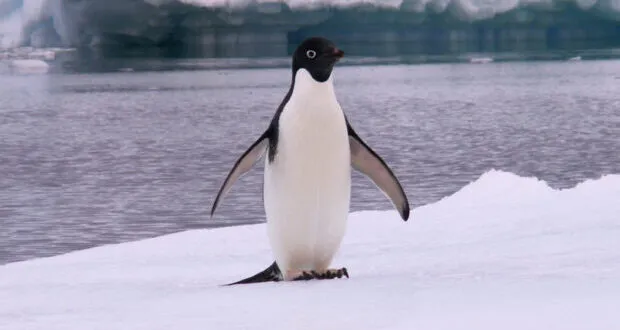

Wczytaj zbiór danych *penguins*:

In [ ]:
data = sn.load_dataset('penguins')
data.head()

---

### Przykład

Jednozmiennowa regresja liniowa przy użyciu `sklearn.linear_models.LinearRegression`.

In [ ]:
data_Adelie = data[data['species'] == 'Adelie'].dropna() # filtrowanie danych tylko do gatunku Adelie i usuwanie wierszy z brakującymi wartościami
feature_list = ['flipper_length_mm'] # cechy używane w modelu
X, y = data_Adelie[feature_list], data_Adelie['body_mass_g']

In [ ]:
X.shape

In [ ]:
lr = LinearRegression() # inicjalizacja modelu
lr.fit(X, y) # dopasowanie modelu do naszych danych
print('Found slope coefficient (w0): ' + str(lr.coef_) + ', intercept (w1): ' + str(lr.intercept_)) # wydruk znalezionych współczynników

# + wizualizacja:
plt.scatter(data_Adelie['flipper_length_mm'], data_Adelie['body_mass_g'], label = 'data')
plt.plot(X, X*lr.coef_ + lr.intercept_, label = 'model')
plt.xlabel('Flipper length (mm)')
plt.ylabel('Body mass (g)')
_ = plt.legend()

---

### Zadanie 1. Wielozmiennowa regresja liniowa.

**Przypomnienie.** SSR (Sum of Squared Residuals) to suma kwadratów reszt:

$$SSR = \sum_{i=1}^{N} (y_i^{pred} - y_i)^2 = (\boldsymbol{y}^{pred} - \boldsymbol{y})^T (\boldsymbol{y}^{pred} - \boldsymbol{y})$$

Im mniejsze SSR, tym lepsze dopasowanie modelu. Dodanie kolejnych cech **nigdy nie zwiększa** SSR (model z większą liczbą parametrów może co najwyżej osiągnąć takie samo dopasowanie).

Rozważmy teraz zależność między długością dzioba (bill_length), głębokością dzioba (bill_depth), długością płetwy (flipper_length) jako (X) a masą ciała (y) dla pingwinów gatunku Adelie. Wytrenuj modele `sklearn.linear_models.LinearRegression` używając 1, 2 i 3 cech. Oblicz SSR (zmodyfikuj zaimplementowaną funkcję, jeśli potrzeba).

In [ ]:
def SSR(w0, w1, x, y):
  ypred = np.dot(x,w0) + w1
  return np.dot((ypred - y).T, (ypred - y))

In [ ]:
data_adelie = data[data['species'] == 'Adelie'].dropna()
SSRs = []
feature_combos = [['flipper_length_mm'], ['bill_length_mm'], ['bill_depth_mm'], ['flipper_length_mm', 'bill_length_mm'], ['flipper_length_mm', 'bill_depth_mm'], ['bill_length_mm', 'bill_depth_mm'], ['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]
for features in feature_combos:
  if len(features) == 1: X, y = np.array(data_adelie[features]).reshape([-1,1]),  np.array(data_adelie['body_mass_g'])
  else: X, y = np.array(data_adelie[features]),  np.array(data_adelie['body_mass_g'])
  lr = LinearRegression()
  lr.fit(X, y)
  SSRs.append(SSR(lr.coef_, lr.intercept_, X, y))
  print(lr.coef_, lr.intercept_, SSRs[-1])

Porównaj wartości SSR i uzyskane współczynniki dla modeli trenowanych na różnej liczbie cech. Narysuj wykres uzyskanych wartości SSR jako funkcję liczby użytych cech. Która pojedyncza cecha najlepiej przewiduje masę ciała pingwina? Czy cechy są ze sobą powiązane?

In [ ]:
# Miejsce na Twoje rozwiązanie

In [ ]:
print(f"Najlepszym pojedynczym predyktorem masy ciała pingwina Adelie jest {feature_combos[np.argmin(SSRs[:3])][0]}.")

Współczynniki wyznaczone dla każdej cechy różnią się w zależności od kombinacji cech, co wskazuje na korelację między cechami. Sprawdźmy współczynniki korelacji Spearmana:

In [ ]:
from scipy.stats import spearmanr

print('flipper_length_mm - bill_length_mm: ', spearmanr(data_adelie['flipper_length_mm'], data_adelie['bill_length_mm']))
print('flipper_length_mm - bill_depth_mm: ', spearmanr(data_adelie['flipper_length_mm'], data_adelie['bill_depth_mm']))
print('bill_depth_mm - bill_length_mm: ', spearmanr(data_adelie['bill_depth_mm'], data_adelie['bill_length_mm']))

---

### Zadanie 2. Współliniowość.

**Współliniowość (multicollinearity)** występuje, gdy zmienne niezależne są silnie ze sobą skorelowane. Konsekwencje:

- Macierz $X^T X$ jest **źle uwarunkowana** (bliski osobliwości) → niestabilne współczynniki
- Współczynniki $w_i$ tracą interpretowalność – mogą się drastycznie zmieniać przy małych zmianach w danych
- Model wciąż może dawać dobre predykcje ($R^2 \approx 1$), ale **współczynniki nie mają sensu fizycznego**

Formalnie: jeśli $x_2 = c \cdot x_1$, to $y = a_1 x_1 + a_2 x_2 = (a_1 + c \cdot a_2) x_1$ – istnieje nieskończenie wiele par $(a_1, a_2)$ spełniających to równanie.

Współczynnik determinacji $R^2$ jest często stosowaną miarą jakości dopasowania regresji:

$$R^2 = 1 - \frac{SSR}{SST} = 1 - \frac{\sum_i (y_i^{pred} - y_i)^2}{\sum_i (y_i - \bar y)^2}$$

Metrykę $R^2$ można traktować jako znormalizowaną miarę błędu modelu: większa wartość $R^2$ oznacza lepszy model regresji.

Dane są dwie zmienne: $x_1$ i $x_2$. Rozważ dwa przypadki:

In [ ]:
x1 = np.random.random(100)
x2 = np.random.random(100)

oraz

In [ ]:
x1 = np.random.random(100)
x2 = np.random.random()*x1

Zmienna $y$ może być wyrażona jako kombinacja liniowa zmiennych $x_1, x_2$:

In [ ]:
y = 5*x1 + 3*x2

Dopasuj modele `sklearn.linear_models.LinearRegression` oraz porównaj współczynniki uzyskane w obu przypadkach. Czy są takie same? Dlaczego? Porównaj wartość `r2_score` obu modeli - który z nich jest lepszy? Które założenie regresji liniowej może zostać naruszone?

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
# Przypadek 1.

# Miejsce na Twoje rozwiązanie

print('Współczynniki: ', ...Miejsce na Twoje rozwiązanie...)
print('Wynik R2: ', ...Miejsce na Twoje rozwiązanie...)

In [ ]:
# Przypadek 2.

# Miejsce na Twoje rozwiązanie

print('Współczynniki: ', ...Miejsce na Twoje rozwiązanie...)
print('Wynik R2: ', ...Miejsce na Twoje rozwiązanie...)

Oba modele mają $R^2 = 1$, co sugeruje, że są równie dobre, ale tylko w przypadku 1 uzyskujemy oczekiwane wartości nachylenia oraz współczynnika: $3$ oraz $5$. Ten przykład pokazuje, jak współliniowość zmiennych może pogorszyć interpretowalność współczynników modelu.

Rozważmy teraz dwie zmienne: $x_1$ oraz $x_2$ oraz zmienną zależną w postaci: $y = a_1 x_1 + a_2 x_2$. Załóżmy teraz, że $x_2 = c x_1$, czyli że $x_2$ jest liniowo zależne od $x_1$. Wtedy zmienna zależna $y = a_1 x_1 + a_2 c x_1 = (a_1 + c a_2) x_1$. Istnieje wiele par $a_1$ oraz $a_2$, które spełniają to równanie!

---

### Zadanie 3. Ocena modelu.

**Przeuczenie (overfitting)** – model zbyt dobrze dopasowuje się do danych treningowych, ale słabo generalizuje na nowe dane.

Aby to wykryć, dzielimy dane na:
- **Zbiór treningowy** – do uczenia modelu,
- **Zbiór testowy** – do oceny generalizacji.

Porównanie $R^2$ na obu zbiorach:
- $R^2_{train} \gg R^2_{test}$ → **przeuczenie** (overfitting),
- $R^2_{train} \approx R^2_{test}$ i oba niskie → **niedouczenie** (underfitting),
- $R^2_{train} \approx R^2_{test}$ i oba wysokie → **dobre dopasowanie**.

W tym zadaniu ocenimy, jak model radzi sobie z wcześniej niewidzianymi danymi. Chcemy przewidzieć jakość wina na podstawie różnych właściwości fizykochemicznych, takich jak kwasowość oraz zawartość alkoholu.

Wykorzystamy jeden ze zbiorów danych udostępnianych przez University of California, Irvine Machine Learning Repository. Pakiet `ucimlrepo` pozwala na łatwy dostęp do tych zbiorów.

In [ ]:
%pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# pobieranie zbioru danych
wine_quality = fetch_ucirepo(id=186)
X = wine_quality.data.features
y = wine_quality.data.targets

X.head()

Podziel dane na część treningową oraz testową. Dopasuj model `sklearn.linear_models.LinearRegression` do danych treningowych i użyj metryki $R^2$, aby ocenić wydajność modelu na zbiorze testowym. Porównaj wydajność modelu na zbiorach treningowym i testowym - co możemy wywnioskować o modelu na podstawie takiego porównania? Możesz użyć metody `sklearn.metrics.r2_score` lub zaimplementować własną funkcję do obliczania współczynnika $R^2$.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
# Miejsce na Twoje rozwiązanie

In [ ]:
print('Wynik R2 na zbiorze treningowym/testowym: ', ...Miejsce na Twoje rozwiązanie...)

Znacznie lepszy wynik na zbiorze treningowym wskazywałby na przeuczenie modelu – model *nie* generalizuje dobrze na nowe dane.

---

### Zadanie 4. (*BONUS*). EDA i selekcja cech.

Jeszcze raz przyjrzymy się zbiorowi danych, który analizowaliśmy w zadaniu 3. Spróbuj poprawić wynik $R^2$ modelu z poprzedniego zadania. Możesz rozważyć wykrywanie wartości odstających, redukcję cech lub inne techniki, aby uzyskać lepsze wyniki.

In [ ]:
# Miejsce na Twoje rozwiązanie

# W razie potrzeby możesz dodać dodatkowe komórki z kodem